# Recreate Figure 1: SQNR(bits) vs Bitrate on Gaussian Source

This notebook recreates the paper-style evaluation on an idealistic Gaussian source.

It follows the metric in the paper:

- draw i.i.d. blocks `w ~ N(0, 1)`,
- quantize each block,
- compute empirical `MSE = mean(||w - q(w)||^2 / D)`,
- report `SQNR_bits = -0.5 * log2(MSE)`,
- compare against the Shannon line `SQNR_bits = R`,
- report retention `100 * SQNR_bits / R`.

Curves included here:

- `LLVQ/Leech (spherical shaping)` using this repo's generated Leech quantizer,
- `QuIP# official E8P/RVQ` using upstream `Cornell-RelaxML/quip-sharp` codebook classes from `third_party/quip-sharp`,
- `E8 (cubic)` using `impl.gaussian_baseline_quantizers.CubicE8Quantizer`,
- `Uniform` using `impl.gaussian_baseline_quantizers.UniformScalarQuantizer`.

This does not run the full QuIP# LLM pipeline: no Hessian LDLQ, randomized Hadamards, CUDA inference kernels, or fine-tuning are used for this Gaussian-source codebook plot.


In [1]:
from __future__ import annotations

import math
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "impl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from impl.gaussian_baseline_quantizers import (
    CubicE8Quantizer,
    QuipSharpE8Quantizer,
    UniformScalarQuantizer,
    mse_to_sqnr_bits,
)
from impl.leech_lattice_vector_quantizer_gpu import DIM, LeechLatticeVectorQuantizerGpu, squared_distance

print(ROOT)


/home/diego/Documents/cvlab/llvq-paper-reproduction


## Configuration

The structured Leech nearest-neighbor search avoids materializing the codebook, but it is still pure Python. Start with a small sample count, then increase `N_SAMPLES` for smoother curves.

The shell cutoff `m=51` reaches exactly `3.0` bits/dim for the cumulative Leech ball by the theta-series count. It can be slow; remove it while iterating.

The QuIP# official points use `E8P12` at 2 bits/dim and `E8P12RVQ3B` at 3 bits/dim.


In [ ]:
SEED = 0
N_SAMPLES = 8

# Cumulative Leech ball cutoffs. m=51 reaches 3.0 bits/dim.
SHELL_CUTOFFS = [2, 3, 4, 5, 6, 8, 10, 13, 20, 30, 31]

# Baseline rates. Integer bits keep the simple baselines honest and fast.
BASELINE_RATES = [1.0, 2.0, 3.0]

# The paper's Figure 1 evaluates iid Gaussian source blocks w ~ N(0, I_24).
# Keep these as synthetic Gaussian noise blocks, not model-weight samples.
GAUSSIAN_SOURCE_MEAN = 0.0
GAUSSIAN_SOURCE_VARIANCE = 1.0
LLVQ_VERBOSE = True

def gaussian_source_blocks(n_samples: int, seed: int = SEED) -> np.ndarray:
    rng = np.random.default_rng(seed)
    sigma = math.sqrt(GAUSSIAN_SOURCE_VARIANCE)
    return rng.normal(GAUSSIAN_SOURCE_MEAN, sigma, size=(n_samples, DIM)).astype(np.float32)

samples = gaussian_source_blocks(N_SAMPLES)
samples.shape, samples.mean(), samples.var()


((8, 24), np.float32(0.012556419), np.float32(0.92848843))

## Evaluation Helpers

In [3]:
def retention_pct(sqnr_bits: float, rate: float) -> float:
    return 100.0 * sqnr_bits / rate


def ideal_gaussian_source_scale(q: LeechLatticeVectorQuantizerGpu, variance: float = GAUSSIAN_SOURCE_VARIANCE) -> float:
    """Quantizer scale: match the finite Leech ball second moment to an iid Gaussian source."""
    weighted_norm2 = sum(2.0 * shell * count for shell, count in q.shell_counts.items())
    average_codebook_norm2 = weighted_norm2 / q.total_count
    source_norm2 = DIM * variance
    return math.sqrt(source_norm2 / average_codebook_norm2)


def evaluate_spherical_shaping(
    max_shell: int,
    samples: np.ndarray,
    variance: float = GAUSSIAN_SOURCE_VARIANCE,
) -> dict:
    """Evaluate LLVQ spherical shaping with ideal Gaussian-source scaling."""
    q = LeechLatticeVectorQuantizerGpu(max_shell=max_shell, verbose=LLVQ_VERBOSE)
    start = time.perf_counter()
    # beta is the quantizer scale, not the source distribution. The samples are already
    # w ~ N(0, I_24); beta maps that unit-variance source onto this finite Leech ball.
    beta = ideal_gaussian_source_scale(q, variance=variance)
    sqerr = 0.0
    indices = []
    for w in samples:
        index = q.quantize(w / beta)
        recon = beta * np.array(q.dequantize(index), dtype=float)
        sqerr += float(np.sum((w - recon) ** 2))
        indices.append(index)
    mse = sqerr / (samples.shape[0] * DIM)

    rate = q.shape_bits / DIM
    sqnr = mse_to_sqnr_bits(mse)
    return {
        "method": "LLVQ/Leech (spherical shaping)",
        "max_shell": max_shell,
        "rate": rate,
        "mse": mse,
        "sqnr_bits": sqnr,
        "retention_pct": retention_pct(sqnr, rate),
        "total_count": q.total_count,
        "shape_bits": q.shape_bits,
        "scale": beta,
        "seconds": time.perf_counter() - start,
        "first_index": indices[0],
    }

def evaluate_uniform(samples: np.ndarray, rates: list[float]) -> list[dict]:
    rows = []
    for rate in rates:
        if abs(rate - round(rate)) > 1e-9:
            continue
        result = UniformScalarQuantizer(bits=int(round(rate))).evaluate(samples)
        rows.append({
            "method": result.method,
            "rate": result.rate,
            "mse": result.mse,
            "sqnr_bits": result.sqnr_bits,
            "scale": result.scale,
            "retention_pct": retention_pct(result.sqnr_bits, result.rate),
            **result.metadata,
        })
    return rows


def evaluate_e8_cubic(samples: np.ndarray, radii: list[float] = [0.5, 1.0, 1.5, 2.0]) -> list[dict]:
    rows = []
    for radius in radii:
        result = CubicE8Quantizer(radius=radius).evaluate(samples)
        rows.append({
            "method": result.method,
            "rate": result.rate,
            "mse": result.mse,
            "sqnr_bits": result.sqnr_bits,
            "scale": result.scale,
            "retention_pct": retention_pct(result.sqnr_bits, result.rate),
            **result.metadata,
        })
    return rows


def evaluate_quip_official(samples: np.ndarray, names: list[str] = ["E8P12", "E8P12RVQ3B"]) -> list[dict]:
    rows = []
    for name in names:
        result = QuipSharpE8Quantizer(name, repo_root=ROOT).evaluate(samples)
        rows.append({
            "method": result.method,
            "rate": result.rate,
            "mse": result.mse,
            "sqnr_bits": result.sqnr_bits,
            "scale": result.scale,
            "retention_pct": retention_pct(result.sqnr_bits, result.rate),
            **result.metadata,
        })
    return rows


def print_row(row: dict) -> None:
    maybe_shell = f"m<={row['max_shell']:2d}  " if "max_shell" in row else "      "
    print(
        f"{row['method']:<34} {maybe_shell}"
        f"R={row['rate']:.4f}  "
        f"MSE={row['mse']:.6f}  "
        f"SQNRbits={row['sqnr_bits']:.4f}  "
        f"Ret={row.get('retention_pct', float('nan')):.1f}%  "
        f"scale={row.get('scale', float('nan')):.3f}"
    )


## Run the Gaussian Benchmark

This cell is the expensive part. With the default small sample count it is meant to be interactive rather than publication-grade.

For fast iteration, temporarily set `SHELL_CUTOFFS = [2, 3, 4, 5, 10]`. For a full 0--3 bits/dim curve, keep `51` in the list.

For LLVQ spherical shaping, the notebook uses idealistic Gaussian-source scaling: `beta` matches the finite Leech ball's average squared norm to `E||w||^2 = DIM` for a unit-variance Gaussian source, then reconstructs `beta * Q(w / beta)`.


In [4]:
llvq_results = []
for max_shell in SHELL_CUTOFFS:
    row = evaluate_spherical_shaping(max_shell, samples)
    llvq_results.append(row)
    print_row(row)

uniform_results = evaluate_uniform(samples, BASELINE_RATES)
e8_cubic_results = evaluate_e8_cubic(samples)
quip_results = evaluate_quip_official(samples)

for row in uniform_results + e8_cubic_results + quip_results:
    print_row(row)


loaded cached class leaders for shell m=2: 3 classes in 0.004s
LLVQ/Leech (spherical shaping)     m<= 2  R=0.7500  MSE=0.440830  SQNRbits=0.5909  Ret=78.8%  scale=2.449
loaded cached class leaders for shell m=2: 3 classes in 0.000s
loaded cached class leaders for shell m=3: 4 classes in 0.000s
LLVQ/Leech (spherical shaping)     m<= 3  R=1.0417  MSE=0.295796  SQNRbits=0.8787  Ret=84.4%  scale=2.004
loaded cached class leaders for shell m=2: 3 classes in 0.000s
loaded cached class leaders for shell m=3: 4 classes in 0.000s
loaded cached class leaders for shell m=4: 8 classes in 0.000s
LLVQ/Leech (spherical shaping)     m<= 4  R=1.2083  MSE=0.216023  SQNRbits=1.1054  Ret=91.5%  scale=1.741
loaded cached class leaders for shell m=2: 3 classes in 0.000s
loaded cached class leaders for shell m=3: 4 classes in 0.000s
loaded cached class leaders for shell m=4: 8 classes in 0.000s
loaded cached class leaders for shell m=5: 9 classes in 0.000s
LLVQ/Leech (spherical shaping)     m<= 5  R=1.3750  

ValueError: Overflow when unpacking long long

## Plot Figure 1 Style Curve

`SQNR_bits = R` is the Shannon limit for a unit-variance Gaussian source under the paper's convention.

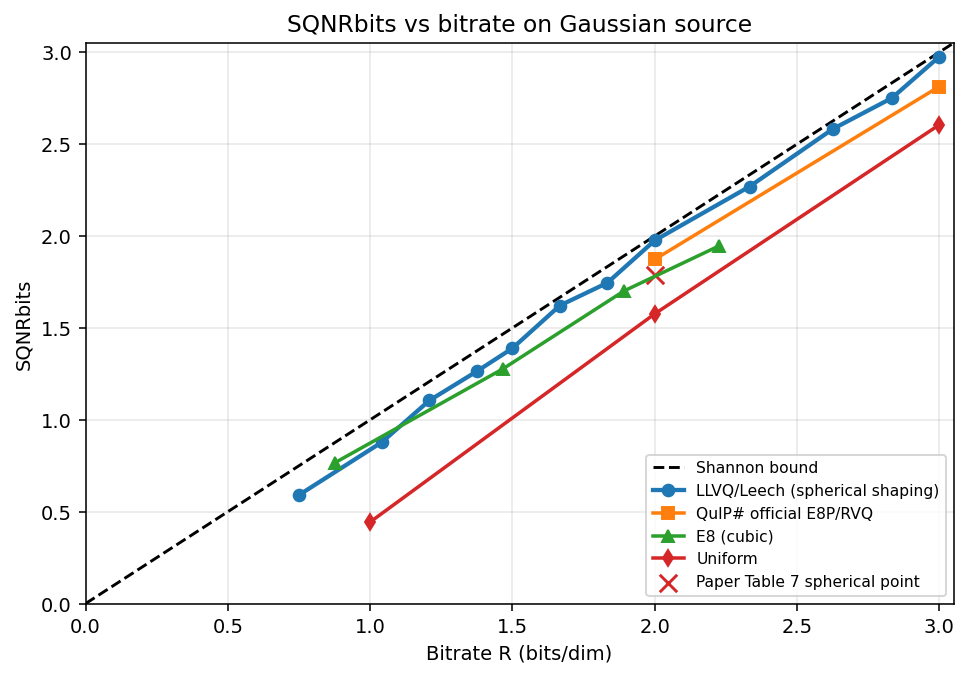

In [ ]:
all_results = llvq_results + uniform_results + e8_cubic_results + quip_results

fig, ax = plt.subplots(figsize=(8.0, 5.2), dpi=140)
x = np.linspace(0.0, 3.05, 200)
ax.plot(x, x, color="black", linewidth=1.5, linestyle="--", label="Shannon bound")

styles = {
    "LLVQ/Leech (spherical shaping)": dict(marker="o", linewidth=2.2),
    "QuIP# official E8P/RVQ": dict(marker="s", linewidth=1.8),
    "E8 (cubic)": dict(marker="^", linewidth=1.8),
    "Uniform": dict(marker="d", linewidth=1.8),
}

for method, style in styles.items():
    rows = sorted([r for r in all_results if r["method"] == method], key=lambda r: r["rate"])
    if not rows:
        continue
    rates = np.array([r["rate"] for r in rows])
    sqnr = np.array([r["sqnr_bits"] for r in rows])
    ax.plot(rates, sqnr, label=method, **style)

# Paper Table 7 sanity marker for spherical shaping at R=2, MSE=0.084.
paper_r = 2.0
paper_mse = 0.084
paper_sqnr = mse_to_sqnr_bits(paper_mse)
ax.scatter([paper_r], [paper_sqnr], marker="x", s=80, color="tab:red", label="Paper Table 7 spherical point")

ax.set_title("SQNRbits vs bitrate on Gaussian source")
ax.set_xlabel("Bitrate R (bits/dim)")
ax.set_ylabel("SQNRbits")
ax.set_xlim(0.0, 3.05)
ax.set_ylim(0.0, 3.05)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.show()


## Inspect One Quantized Block

The index decodes to an integer representative in `Lint`; the actual Leech lattice reconstruction is scaled by `1/sqrt(8)`. This is why the dequantized values are real numbers even though the index hierarchy is integer-valued.

In [ ]:
q = LeechLatticeVectorQuantizerGpu(max_shell=SHELL_CUTOFFS[-1], verbose=LLVQ_VERBOSE)
w = samples[0]
beta = ideal_gaussian_source_scale(q)
idx = q.quantize(w / beta)
ranked = q.unrank(idx)

print("input:", np.round(w, 4))
print("index:", idx)
print("address:", ranked)
print("integer representative:", q.dequantize(idx))
recon = beta * np.array(q.dequantize(idx), dtype=float)
print("scaled reconstruction:", np.round(recon, 4))
print("block MSE:", float(np.mean((w - recon) ** 2)))


input: [ 0.1257 -0.1321  0.6404  0.1049 -0.5357  0.3616  1.304   0.9471 -0.7037
 -1.2654 -0.6233  0.0413 -2.325  -0.2188 -1.2459 -0.7323 -0.5443 -0.3163
  0.4116  1.0425 -0.1285  1.3665 -0.6652  0.3515]
index: 3696071938165
address: RankedCodeword(global_index=3696071938165, shell=9, shell_local_index=2654240187205, class_index=17, class_local_index=13666067269, class_offset=2640574119936, leader=ClassLeader(shell=9, parity='odd', count=80333045760, mult_abs8=0, mult_abs6=0, mult_abs5=0, mult_abs4=0, mult_abs3=9, mult_abs2=0, mult_abs1=14, mult_abs0=0, extra_multiplicities=((7, 1),)))
integer representative: (1, 1, 3, 1, -1, 1, 3, 3, -1, -3, -3, 1, -7, -1, -3, -3, -1, -1, 1, 3, -1, 3, -1, 1)
scaled reconstruction: [ 0.3536  0.3536  1.0607  0.3536 -0.3536  0.3536  1.0607  1.0607 -0.3536
 -1.0607 -1.0607  0.3536 -2.4749 -0.3536 -1.0607 -1.0607 -0.3536 -0.3536
  0.3536  1.0607 -0.3536  1.0607 -0.3536  0.3536]
block MSE: 0.06459971188702225
